In [1]:
# Week 4: Supervised Learning
# AnalystLab Africa Internship
# Thembinkosi Spogter Phama

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Load cleaned datasets
base_path = r'C:\Users\THEMBINKOSI\Desktop\AnalystLab_Internship\datasets'
titanic = pd.read_csv(f'{base_path}\\titanic_cleaned.csv')
housing = pd.read_csv(f'{base_path}\\housing_cleaned.csv')

print("✅ Week 4 ready!")
print(f"Titanic: {titanic.shape}")
print(f"Housing: {housing.shape}")

✅ Week 4 ready!
Titanic: (891, 11)
Housing: (545, 13)


TASK 1: LINEAR REGRESSION — HOUSE PRICE PREDICTION
Features: 12 columns
Target: price
Samples: 545

Training set: 436 samples
Test set: 109 samples

MODEL PERFORMANCE — Linear Regression
RMSE:        1,331,071.42
R2 Score:    0.6495 (64.95%)


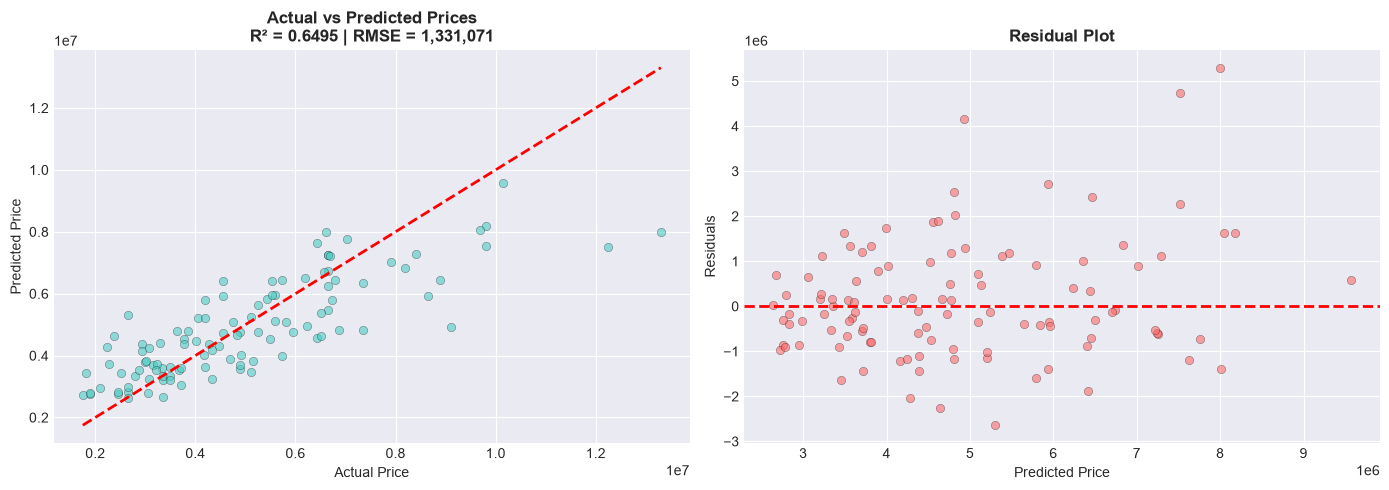


Feature Importance (Coefficients):
  bathrooms           : 1,097,117.27 ↑
  airconditioning     :   785,550.58 ↑
  hotwaterheating     :   687,881.31 ↑
  prefarea            :   629,901.66 ↑
  stories             :   406,223.16 ↑
  basement            :   393,159.78 ↑
  mainroad            :   366,824.19 ↑
  guestroom           :   233,146.77 ↑
  parking             :   225,756.51 ↑
  bedrooms            :    78,574.49 ↑
  area                :       235.85 ↑
  furnishingstatus    :  -210,397.12 ↓


In [2]:
print("=" * 60)
print("TASK 1: LINEAR REGRESSION — HOUSE PRICE PREDICTION")
print("=" * 60)

# Step 1: Prepare data
# Encode categorical variables
le = LabelEncoder()
housing_encoded = housing.copy()
cat_cols = housing_encoded.select_dtypes(include='object').columns
for col in cat_cols:
    housing_encoded[col] = le.fit_transform(housing_encoded[col])

# Features (X) and Target (y)
X = housing_encoded.drop('price', axis=1)
y = housing_encoded['price']

print(f"Features: {X.shape[1]} columns")
print(f"Target: price")
print(f"Samples: {X.shape[0]}")

# Step 2: Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Step 3: Train Linear Regression Model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Step 4: Make Predictions
y_pred = model_lr.predict(X_test)

# Step 5: Evaluate Model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n{'='*40}")
print(f"MODEL PERFORMANCE — Linear Regression")
print(f"{'='*40}")
print(f"RMSE:        {rmse:,.2f}")
print(f"R2 Score:    {r2:.4f} ({r2*100:.2f}%)")
print(f"{'='*40}")

# Step 6: Visualize Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.6, color='#4ECDC4', edgecolors='black', linewidth=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Actual vs Predicted Prices\nR² = {r2:.4f} | RMSE = {rmse:,.0f}', fontweight='bold')

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='#FF6B6B', edgecolors='black', linewidth=0.3)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.tight_layout()
plt.show()

# Feature Importance (Coefficients)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_lr.coef_
}).sort_values('Coefficient', ascending=False)

print("\nFeature Importance (Coefficients):")
for _, row in feature_importance.iterrows():
    direction = "↑" if row['Coefficient'] > 0 else "↓"
    print(f"  {row['Feature']:20s}: {row['Coefficient']:>12,.2f} {direction}")

TASK 2: LOGISTIC REGRESSION — TITANIC SURVIVAL PREDICTION
Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Target: Survived
Samples: 891

Training set: 712 samples
Test set: 179 samples

MODEL PERFORMANCE — Logistic Regression
Accuracy:    0.8101 (81.01%)

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.84       105
       Survived       0.79      0.74      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179



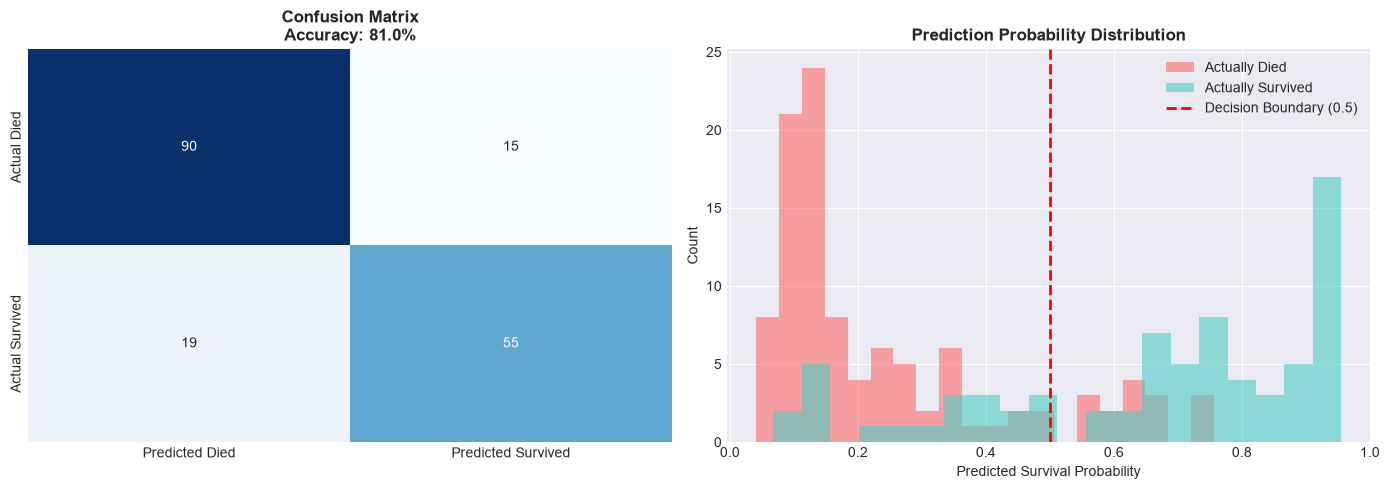


Feature Importance (Log-Odds):
  Fare           :     0.0025  ↑ Survival
  Age            :    -0.0304  ↓ Survival
  Parch          :    -0.1119  ↓ Survival
  Embarked       :    -0.2188  ↓ Survival
  SibSp          :    -0.2939  ↓ Survival
  Pclass         :    -0.9307  ↓ Survival
  Sex            :    -2.5970  ↓ Survival


In [3]:
print("=" * 60)
print("TASK 2: LOGISTIC REGRESSION — TITANIC SURVIVAL PREDICTION")
print("=" * 60)

# Step 1: Prepare data
titanic_ml = titanic.copy()

# Drop columns that won't help prediction
drop_cols = ['PassengerId', 'Name', 'Ticket']
titanic_ml = titanic_ml.drop(drop_cols, axis=1)

# Encode categorical variables
le = LabelEncoder()
cat_cols = ['Sex', 'Embarked']
for col in cat_cols:
    titanic_ml[col] = le.fit_transform(titanic_ml[col])

# Features (X) and Target (y)
X = titanic_ml.drop('Survived', axis=1)
y = titanic_ml['Survived']

print(f"Features: {list(X.columns)}")
print(f"Target: Survived")
print(f"Samples: {X.shape[0]}")

# Step 2: Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Step 3: Train Logistic Regression Model
model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train, y_train)

# Step 4: Make Predictions
y_pred = model_log.predict(X_test)

# Step 5: Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\n{'='*40}")
print(f"MODEL PERFORMANCE — Logistic Regression")
print(f"{'='*40}")
print(f"Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"{'='*40}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

# Step 6: Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Died', 'Predicted Survived'],
            yticklabels=['Actual Died', 'Actual Survived'],
            ax=axes[0], cbar=False)
axes[0].set_title(f'Confusion Matrix\nAccuracy: {accuracy*100:.1f}%', fontweight='bold', fontsize=12)

# Survival Probability Distribution
y_prob = model_log.predict_proba(X_test)[:, 1]
axes[1].hist(y_prob[y_test==0], bins=20, alpha=0.6, label='Actually Died', color='#FF6B6B')
axes[1].hist(y_prob[y_test==1], bins=20, alpha=0.6, label='Actually Survived', color='#4ECDC4')
axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary (0.5)')
axes[1].set_xlabel('Predicted Survival Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Probability Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Feature Importance (Coefficients)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_log.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("\nFeature Importance (Log-Odds):")
for _, row in feature_importance.iterrows():
    direction = "↑ Survival" if row['Coefficient'] > 0 else "↓ Survival"
    print(f"  {row['Feature']:15s}: {row['Coefficient']:>10.4f}  {direction}")

WEEK 4: SUPERVISED LEARNING — MODEL PERFORMANCE SUMMARY

  Metric                       Linear Regression    Logistic Regression
  ----------------------------------------------------------------------
  Task                       Predict House Price       Predict Survival
  Dataset                     Housing (545 rows)     Titanic (891 rows)
  Test Size                          109 samples            179 samples
                                                                       
  Key Metric                     RMSE: 1,331,071       Accuracy: 81.01%
                             R²: 0.6495 (64.95%)                       
  ----------------------------------------------------------------------


KEY INSIGHTS

🏠 HOUSE PRICE PREDICTION (Linear Regression):
   - Model explains 64.95% of price variance
   - Average prediction error: ±1,331,071
   - Top drivers: Bathrooms, Air Conditioning, Hot Water Heating

🚢 TITANIC SURVIVAL PREDICTION (Logistic Regression):
   - 81.01% accuracy — st

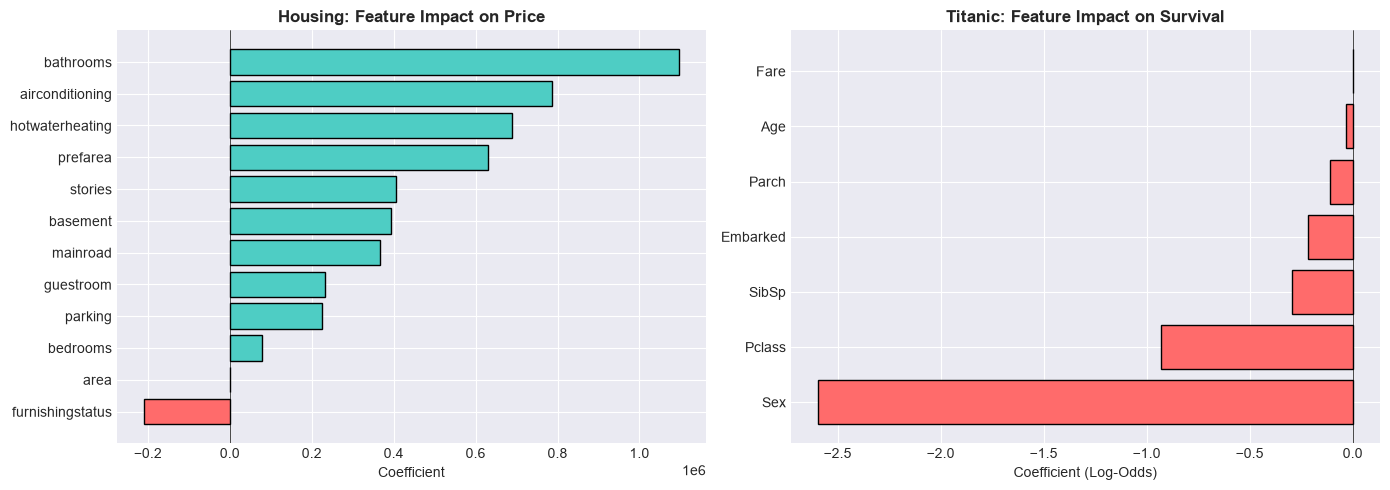


✅ Model comparison complete!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# Load data
base_path = r'C:\Users\THEMBINKOSI\Desktop\AnalystLab_Internship\datasets'
titanic = pd.read_csv(f'{base_path}\\titanic_cleaned.csv')
housing = pd.read_csv(f'{base_path}\\housing_cleaned.csv')

# ═══════════════════════════════════════════════
# HOUSING - Linear Regression
# ═══════════════════════════════════════════════
le = LabelEncoder()
housing_encoded = housing.copy()
cat_cols = housing_encoded.select_dtypes(include='object').columns
for col in cat_cols:
    housing_encoded[col] = le.fit_transform(housing_encoded[col])

X_housing = housing_encoded.drop('price', axis=1)
y_housing = housing_encoded['price']

Xh_train, Xh_test, yh_train, yh_test = train_test_split(X_housing, y_housing, test_size=0.2, random_state=42)

model_lr = LinearRegression()
model_lr.fit(Xh_train, yh_train)
yh_pred = model_lr.predict(Xh_test)

rmse = np.sqrt(mean_squared_error(yh_test, yh_pred))
r2 = r2_score(yh_test, yh_pred)

# ═══════════════════════════════════════════════
# TITANIC - Logistic Regression
# ═══════════════════════════════════════════════
titanic_ml = titanic.copy()
drop_cols = ['PassengerId', 'Name', 'Ticket']
titanic_ml = titanic_ml.drop(drop_cols, axis=1)

for col in ['Sex', 'Embarked']:
    titanic_ml[col] = le.fit_transform(titanic_ml[col])

X_titanic = titanic_ml.drop('Survived', axis=1)
y_titanic = titanic_ml['Survived']

Xt_train, Xt_test, yt_train, yt_test = train_test_split(X_titanic, y_titanic, test_size=0.2, random_state=42)

model_log = LogisticRegression(max_iter=1000)
model_log.fit(Xt_train, yt_train)
yt_pred = model_log.predict(Xt_test)

accuracy = accuracy_score(yt_test, yt_pred)

# ═══════════════════════════════════════════════
# MODEL COMPARISON SUMMARY
# ═══════════════════════════════════════════════
print("=" * 70)
print("WEEK 4: SUPERVISED LEARNING — MODEL PERFORMANCE SUMMARY")
print("=" * 70)

print(f"""
  {'Metric':<25} {'Linear Regression':>20} {'Logistic Regression':>22}
  {'-'*70}
  {'Task':<25} {'Predict House Price':>20} {'Predict Survival':>22}
  {'Dataset':<25} {'Housing (545 rows)':>20} {'Titanic (891 rows)':>22}
  {'Test Size':<25} {f'{Xh_test.shape[0]} samples':>20} {f'{Xt_test.shape[0]} samples':>22}
  {'':<25} {'' :>20} {'' :>22}
  {'Key Metric':<25} {f'RMSE: {rmse:,.0f}':>20} {f'Accuracy: {accuracy*100:.2f}%':>22}
  {'':<25} {f'R²: {r2:.4f} ({r2*100:.2f}%)':>20} {'':>22}
  {'-'*70}
""")

print("\nKEY INSIGHTS")
print("=" * 70)
print(f"""
🏠 HOUSE PRICE PREDICTION (Linear Regression):
   - Model explains {r2*100:.2f}% of price variance
   - Average prediction error: ±{rmse:,.0f}
   - Top drivers: Bathrooms, Air Conditioning, Hot Water Heating

🚢 TITANIC SURVIVAL PREDICTION (Logistic Regression):
   - {accuracy*100:.2f}% accuracy — strong baseline model
   - Sex is the most powerful predictor (coefficient: -2.60)
   - Pclass (-0.93) is second most important
""")

# ═══════════════════════════════════════════════
# VISUAL COMPARISON
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Housing Feature Importance
housing_coefs = pd.DataFrame({
    'Feature': X_housing.columns,
    'Coefficient': model_lr.coef_
}).sort_values('Coefficient')
colors_h = ['#FF6B6B' if c < 0 else '#4ECDC4' for c in housing_coefs['Coefficient']]
axes[0].barh(housing_coefs['Feature'], housing_coefs['Coefficient'], color=colors_h, edgecolor='black')
axes[0].set_title('Housing: Feature Impact on Price', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Coefficient')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# Titanic Feature Importance
titanic_coefs = pd.DataFrame({
    'Feature': X_titanic.columns,
    'Coefficient': model_log.coef_[0]
}).sort_values('Coefficient')
colors_t = ['#4ECDC4' if c > 0 else '#FF6B6B' for c in titanic_coefs['Coefficient']]
axes[1].barh(titanic_coefs['Feature'], titanic_coefs['Coefficient'], color=colors_t, edgecolor='black')
axes[1].set_title('Titanic: Feature Impact on Survival', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Coefficient (Log-Odds)')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n✅ Model comparison complete!")

In [3]:
import joblib
import os

models_path = r'C:\Users\THEMBINKOSI\Desktop\AnalystLab_Internship\models'
os.makedirs(models_path, exist_ok=True)

joblib.dump(model_lr, f'{models_path}\\linear_regression_housing.pkl')
joblib.dump(model_log, f'{models_path}\\logistic_regression_titanic.pkl')

print("✅ Models saved!")

✅ Models saved!


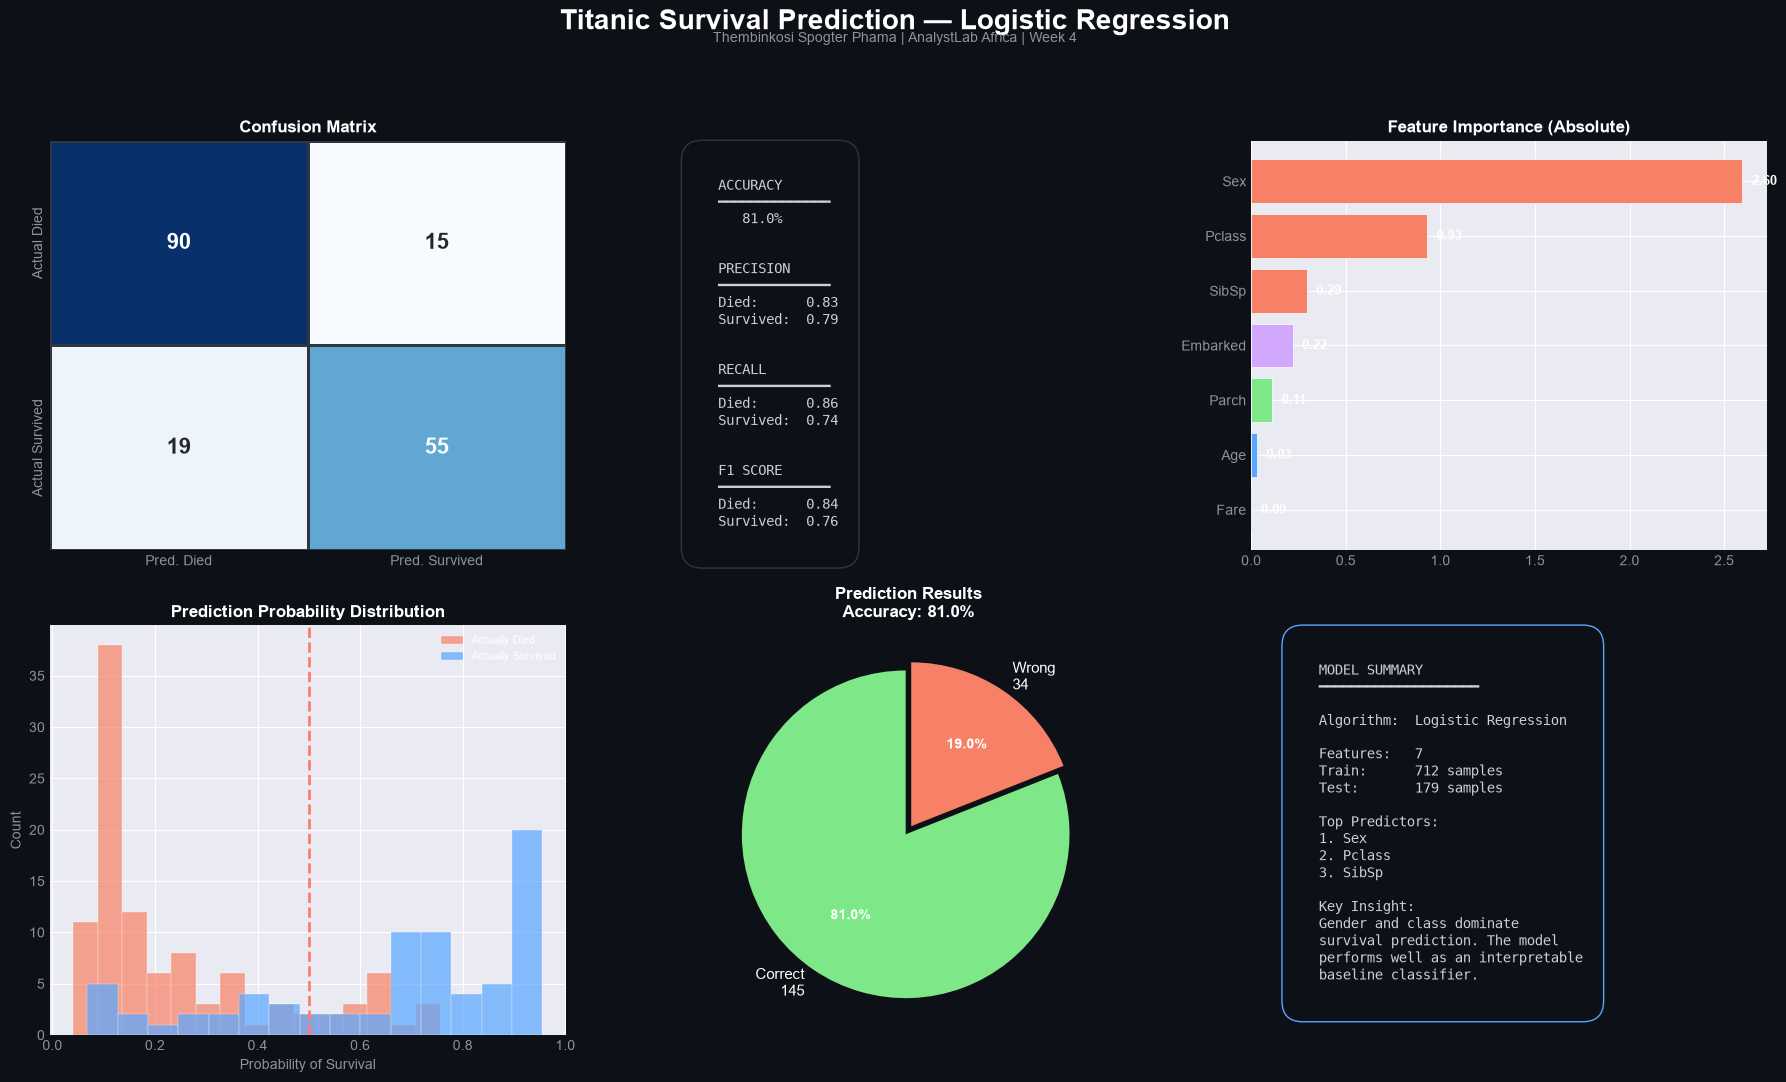

✅ Clean Titanic Dashboard saved!


In [11]:
# ═══════════════════════════════════════════════
# TITANIC — CLEAN LOGISTIC REGRESSION DASHBOARD
# ═══════════════════════════════════════════════

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Titanic Survival Prediction — Logistic Regression', fontsize=20, fontweight='bold', color='white', y=0.98)
fig.text(0.5, 0.95, 'Thembinkosi Spogter Phama | AnalystLab Africa | Week 4', 
         fontsize=10, ha='center', color='#8b949e')

# ═══ ROW 1: Confusion Matrix + Metrics + Feature Importance ═══

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
cm = confusion_matrix(yt_test, yt_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred. Died', 'Pred. Survived'],
            yticklabels=['Actual Died', 'Actual Survived'],
            ax=ax1, cbar=False, annot_kws={'fontsize': 16, 'fontweight': 'bold'},
            linewidths=1, linecolor='#30363d')
ax1.set_title('Confusion Matrix', color='white', fontweight='bold', fontsize=12)
ax1.tick_params(colors='#8b949e', labelsize=10)

# 2. Key Metrics
ax2 = plt.subplot(2, 3, 2)
ax2.axis('off')
ax2.set_facecolor('#161b22')
report = classification_report(yt_test, yt_pred, target_names=['Died', 'Survived'], output_dict=True)

metrics = f"""
  ACCURACY
  ━━━━━━━━━━━━━━
     {accuracy*100:.1f}%


  PRECISION
  ━━━━━━━━━━━━━━
  Died:      {report['Died']['precision']:.2f}
  Survived:  {report['Survived']['precision']:.2f}


  RECALL
  ━━━━━━━━━━━━━━
  Died:      {report['Died']['recall']:.2f}
  Survived:  {report['Survived']['recall']:.2f}


  F1 SCORE
  ━━━━━━━━━━━━━━
  Died:      {report['Died']['f1-score']:.2f}
  Survived:  {report['Survived']['f1-score']:.2f}
"""
ax2.text(0.1, 0.95, metrics, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace', color='#c9d1d9',
         bbox=dict(boxstyle='round', facecolor='#0d1117', edgecolor='#30363d', pad=1.5))

# 3. Feature Importance
ax3 = plt.subplot(2, 3, 3)
coefs = pd.DataFrame({'Feature': X_titanic.columns, 'Importance': np.abs(model_log.coef_[0])}).sort_values('Importance')
colors_bar = ['#58a6ff', '#58a6ff', '#7ee787', '#d2a8ff', '#f78166', '#f78166', '#f78166']
bars = ax3.barh(coefs['Feature'], coefs['Importance'], color=colors_bar, edgecolor='white', linewidth=0.5)
ax3.set_title('Feature Importance (Absolute)', color='white', fontweight='bold', fontsize=12)
ax3.tick_params(colors='#8b949e', labelsize=10)
for bar, val in zip(bars, coefs['Importance']):
    ax3.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', 
             va='center', color='white', fontweight='bold', fontsize=9)

# ═══ ROW 2: Probability Distribution + Prediction Results + Summary ═══

# 4. Prediction Probability
ax4 = plt.subplot(2, 3, 4)
y_prob = model_log.predict_proba(Xt_test)[:, 1]
ax4.hist(y_prob[yt_test == 0], bins=15, alpha=0.7, label='Actually Died', color='#f78166', edgecolor='white', linewidth=0.3)
ax4.hist(y_prob[yt_test == 1], bins=15, alpha=0.7, label='Actually Survived', color='#58a6ff', edgecolor='white', linewidth=0.3)
ax4.axvline(x=0.5, color='#ff7b72', linestyle='--', linewidth=2)
ax4.set_title('Prediction Probability Distribution', color='white', fontweight='bold', fontsize=12)
ax4.set_xlabel('Probability of Survival', color='#8b949e')
ax4.set_ylabel('Count', color='#8b949e')
ax4.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='white', fontsize=8)
ax4.tick_params(colors='#8b949e')

# 5. Correct vs Wrong
ax5 = plt.subplot(2, 3, 5)
comparison = pd.DataFrame({'Actual': yt_test.values, 'Predicted': yt_pred})
correct = (comparison['Actual'] == comparison['Predicted']).sum()
wrong = len(comparison) - correct
wedges, texts, autotexts = ax5.pie([correct, wrong], 
                                     labels=[f'Correct\n{correct}', f'Wrong\n{wrong}'],
                                     colors=['#7ee787', '#f78166'], 
                                     autopct='%1.1f%%', startangle=90,
                                     explode=(0.03, 0.03))
for t in texts:
    t.set_color('white')
    t.set_fontsize(11)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
ax5.set_title(f'Prediction Results\nAccuracy: {accuracy*100:.1f}%', color='white', fontweight='bold', fontsize=12)

# 6. Summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
ax6.set_facecolor('#161b22')
summary = f"""
  MODEL SUMMARY
  ━━━━━━━━━━━━━━━━━━━━

  Algorithm:  Logistic Regression

  Features:   {X_titanic.shape[1]}
  Train:      {Xt_train.shape[0]} samples
  Test:       {Xt_test.shape[0]} samples

  Top Predictors:
  1. Sex
  2. Pclass
  3. SibSp

  Key Insight:
  Gender and class dominate
  survival prediction. The model
  performs well as an interpretable
  baseline classifier.
"""
ax6.text(0.1, 0.95, summary, transform=ax6.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace', color='#c9d1d9',
         bbox=dict(boxstyle='round', facecolor='#0d1117', edgecolor='#58a6ff', pad=1.5))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f'{fig_path}\\dashboards\\titanic_classification_dashboard.png', dpi=200, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Clean Titanic Dashboard saved!")

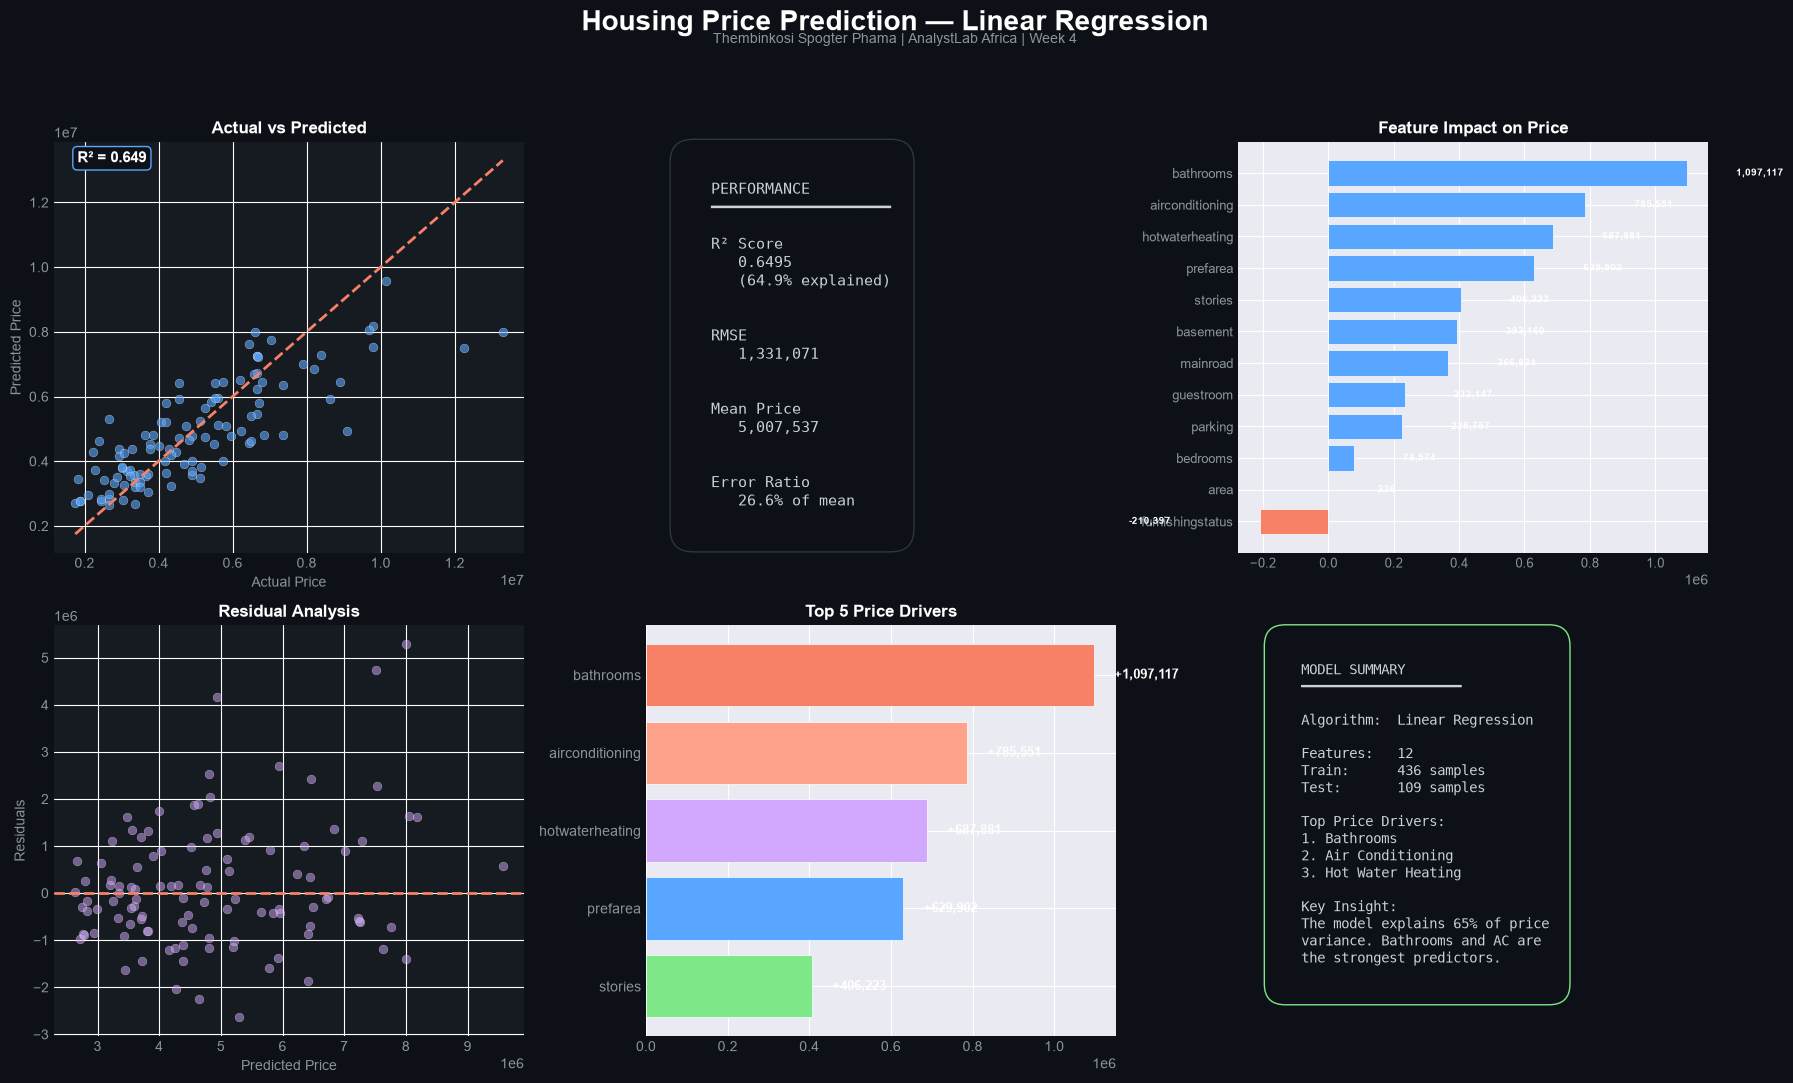

✅ Clean Housing Dashboard saved!


In [12]:
# ═══════════════════════════════════════════════
# HOUSING — CLEAN LINEAR REGRESSION DASHBOARD
# ═══════════════════════════════════════════════

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Housing Price Prediction — Linear Regression', fontsize=20, fontweight='bold', color='white', y=0.98)
fig.text(0.5, 0.95, 'Thembinkosi Spogter Phama | AnalystLab Africa | Week 4', 
         fontsize=10, ha='center', color='#8b949e')

# ═══ ROW 1 ═══

# 1. Actual vs Predicted
ax1 = plt.subplot(2, 3, 1)
ax1.set_facecolor('#161b22')
ax1.scatter(yh_test, yh_pred, alpha=0.6, color='#58a6ff', edgecolors='white', linewidth=0.3, s=40)
ax1.plot([yh_test.min(), yh_test.max()], [yh_test.min(), yh_test.max()], '--', color='#f78166', linewidth=2)
ax1.set_xlabel('Actual Price', color='#8b949e')
ax1.set_ylabel('Predicted Price', color='#8b949e')
ax1.set_title('Actual vs Predicted', color='white', fontweight='bold', fontsize=12)
ax1.tick_params(colors='#8b949e')
ax1.text(0.05, 0.95, f'R² = {r2:.3f}', transform=ax1.transAxes, fontsize=11,
         color='white', fontweight='bold', bbox=dict(boxstyle='round', facecolor='#0d1117', edgecolor='#58a6ff'))

# 2. Performance Metrics
ax2 = plt.subplot(2, 3, 2)
ax2.axis('off')
ax2.set_facecolor('#161b22')
h_metrics = f"""
  PERFORMANCE
  ━━━━━━━━━━━━━━━━━━━━

  R² Score
     {r2:.4f}
     ({r2*100:.1f}% explained)


  RMSE
     {rmse:,.0f}


  Mean Price
     {yh_test.mean():,.0f}


  Error Ratio
     {rmse/yh_test.mean()*100:.1f}% of mean
"""
ax2.text(0.1, 0.95, h_metrics, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace', color='#c9d1d9',
         bbox=dict(boxstyle='round', facecolor='#0d1117', edgecolor='#30363d', pad=1.5))

# 3. Feature Importance
ax3 = plt.subplot(2, 3, 3)
h_coefs = pd.DataFrame({'Feature': X_housing.columns, 'Coefficient': model_lr.coef_}).sort_values('Coefficient')
h_colors = ['#f78166' if c < 0 else '#58a6ff' for c in h_coefs['Coefficient']]
bars = ax3.barh(h_coefs['Feature'], h_coefs['Coefficient'], color=h_colors, edgecolor='white', linewidth=0.5)
ax3.set_title('Feature Impact on Price', color='white', fontweight='bold', fontsize=12)
ax3.axvline(x=0, color='white', linewidth=0.5)
ax3.tick_params(colors='#8b949e', labelsize=9)
for bar, val in zip(bars, h_coefs['Coefficient']):
    offset = 150000 if val >= 0 else -400000
    ax3.text(val + offset, bar.get_y() + bar.get_height()/2, f'{val:,.0f}', 
             va='center', color='white', fontweight='bold', fontsize=7)

# ═══ ROW 2 ═══

# 4. Residual Plot
ax4 = plt.subplot(2, 3, 4)
residuals = yh_test - yh_pred
ax4.set_facecolor('#161b22')
ax4.scatter(yh_pred, residuals, alpha=0.5, color='#d2a8ff', edgecolors='white', linewidth=0.3, s=40)
ax4.axhline(y=0, color='#f78166', linestyle='--', linewidth=2)
ax4.set_xlabel('Predicted Price', color='#8b949e')
ax4.set_ylabel('Residuals', color='#8b949e')
ax4.set_title('Residual Analysis', color='white', fontweight='bold', fontsize=12)
ax4.tick_params(colors='#8b949e')

# 5. Top 5 Drivers
ax5 = plt.subplot(2, 3, 5)
top5 = h_coefs.tail(5)
top_colors = ['#7ee787', '#58a6ff', '#d2a8ff', '#ffa28b', '#f78166']
ax5.barh(top5['Feature'], top5['Coefficient'], color=top_colors, edgecolor='white', linewidth=0.5)
ax5.set_title('Top 5 Price Drivers', color='white', fontweight='bold', fontsize=12)
ax5.tick_params(colors='#8b949e', labelsize=10)
for bar, val in zip(ax5.patches, top5['Coefficient']):
    ax5.text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2, f'+{val:,.0f}', 
             va='center', color='white', fontweight='bold', fontsize=9)

# 6. Model Summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
ax6.set_facecolor('#161b22')
h_summary = f"""
  MODEL SUMMARY
  ━━━━━━━━━━━━━━━━━━━━

  Algorithm:  Linear Regression

  Features:   {X_housing.shape[1]}
  Train:      {Xh_train.shape[0]} samples
  Test:       {Xh_test.shape[0]} samples

  Top Price Drivers:
  1. Bathrooms
  2. Air Conditioning
  3. Hot Water Heating

  Key Insight:
  The model explains {r2*100:.0f}% of price
  variance. Bathrooms and AC are
  the strongest predictors.
"""
ax6.text(0.1, 0.95, h_summary, transform=ax6.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace', color='#c9d1d9',
         bbox=dict(boxstyle='round', facecolor='#0d1117', edgecolor='#7ee787', pad=1.5))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f'{fig_path}\\dashboards\\housing_regression_dashboard.png', dpi=200, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Clean Housing Dashboard saved!")

✅ Week 4 Model Evaluation Report saved!
